<a href="https://colab.research.google.com/github/EngMohamed-op/supervised-and-unsupervised-project/blob/main/WorldCup2026Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#World Cup 2026 — Match Prediction & Tournament Simulator
##UNIT 4&5 Machine Learning Project — Football Analytics



**Dataset 1** : International football results from 1872 to 2026

**Source** : Kaggle - [International football results from 1872 to 2026](https://www.kaggle.com/datasets/martj42/international-football-results-from-1872-to-2017)
____________________________________________

**Dataset 2** : FIFA World Ranking 1992-2024

**Source** : Kaggle - [FIFA World Ranking 1992-2024](https://www.kaggle.com/datasets/cashncarry/fifaworldranking)

#Project outline :
1. Dataset description & problem definition
2. Data loading & structure
3. Data cleaning & preprocessing
4. Elo engine & feature engineering
5. Exploratory data analysis (EDA)
6. Machine learning models
7. World Cup simulation (Monte Carlo)
8. Deployment — FastAPI + Streamlit App

#Step 1 — Dataset Description & Problem Definition :

This project uses 5 interconnected football datasets covering every international match since 1872, FIFA ranking snapshots from 1992 to 2024, individual goal events, penalty shoot-out records, and historical country name changes. Together they allow us to reconstruct the full strength history of every national team and simulate the FIFA World Cup 2026 with probabilistic, data-driven match predictions.


1. International Football Results (1872 - 2026)
What is this dataset about?
This dataset contains a complete record of international football matches starting from the first official match in 1872 up to 2026. It includes essential details such as home and away teams, scores, tournament types (from friendlies to FIFA World Cups), match dates, and the specific city and country where each game was played. It provides a historical timeline of how the sport has grown and shifted globally over more than 150 years.

kaggle [International football results from 1872 to 2026](https://www.kaggle.com/datasets/martj42/international-football-results-from-1872-to-2017)



2. FIFA World Ranking (1992 - 2024)
What is this dataset about?
This dataset tracks the official FIFA World Rankings for national teams from their inception in 1992 through 2024. It includes key metrics such as the team’s total points, current rank, previous rank, and the federation they belong to (e.g., UEFA, AFC). This data allows for the analysis of team consistency, the rise of emerging nations, and how FIFA’s points system has evaluated the strength of national teams over the last three decades.

kaggle : [FIFA World Ranking 1992-2024](https://www.kaggle.com/datasets/cashncarry/fifaworldranking)

#Main questions we will explore


*   Can Elo ratings reliably predict the winner of a football match between any two national teams?
*   Which team is most likely to win the 2026 World Cup, and with what probability?
*   Do stronger teams (higher Elo) consistently beat weaker ones, or do upsets follow a pattern?
*   How does home advantage quantifiably affect match outcomes?
*   Which confederation produces the most consistently elite teams over 20+ years?
*   Can we cluster national teams into meaningful tiers (strong / medium / weak) using unsupervised learning?



#What insights do we expect?


*   Elo difference will be the single strongest predictor of match outcome, outperforming raw FIFA rank.
*   Argentina & France will emerge as co-favourites in the Monte Carlo simulation with 1,000+ runs.
*   Home advantage adds roughly +100 Elo points of effective strength — measurable and statistically significant.
*   UEFA & CONMEBOL teams will cluster clearly above other confederations in the unsupervised tier model.


##Step 2A — Install & Import Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib
#matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import pearsonr
from collections import defaultdict
from google.colab import files


#Step 2B — Load the Dataset

In [2]:
uploaded = files.upload()

Saving fifa_ranking-2024-06-20.csv to fifa_ranking-2024-06-20 (3).csv
Saving former_names.csv to former_names (3).csv
Saving goalscorers.csv to goalscorers (3).csv
Saving results.csv to results (3).csv
Saving shootouts.csv to shootouts (3).csv


In [3]:
# SECTION 1- DATA LOADING & PREPROCESSING
print("_" * 60)
print(" 1- Loading datasets : ")
print("_" * 60)

df_results    = pd.read_csv(f"results.csv")
df_fifa       = pd.read_csv(f"fifa_ranking-2024-06-20.csv")
df_goals      = pd.read_csv(f"goalscorers.csv")
df_shootouts  = pd.read_csv(f"shootouts.csv")
df_former     = pd.read_csv(f"former_names.csv")

print("\nTable Shapes:")
for name, df in [("results", df_results), ("fifa_ranking", df_fifa),
                 ("goalscorers", df_goals), ("shootouts", df_shootouts),
                 ("former_names", df_former)]:
    print(f"   {name:20s}  {df.shape[0]:>6,} rows × {df.shape[1]} cols")


____________________________________________________________
 1- Loading datasets : 
____________________________________________________________

Table Shapes:
   results               49,071 rows × 9 cols
   fifa_ranking          67,472 rows × 8 cols
   goalscorers           47,555 rows × 8 cols
   shootouts                665 rows × 5 cols
   former_names              36 rows × 4 cols


#Step 3 — Data Structure and Data Cleaning (per table)

#1. Results table (results.csv) : df_result

In [4]:
df_results.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False


In [5]:
df_results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49071 entries, 0 to 49070
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        49071 non-null  object
 1   home_team   49071 non-null  object
 2   away_team   49071 non-null  object
 3   home_score  49071 non-null  int64 
 4   away_score  49071 non-null  int64 
 5   tournament  49071 non-null  object
 6   city        49071 non-null  object
 7   country     49071 non-null  object
 8   neutral     49071 non-null  bool  
dtypes: bool(1), int64(2), object(6)
memory usage: 3.0+ MB


In [6]:
missing = df_results.isnull().sum()
missing_pct = (missing / len(df_results) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('═' * 45)
print('  df_results - MISSING VALUES REPORT')
print('═' * 45)
print(missing_df.to_string())
print(f'\n Total columns with missing data: {len(missing_df)}')

═════════════════════════════════════════════
  df_results - MISSING VALUES REPORT
═════════════════════════════════════════════
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

 Total columns with missing data: 0


In [7]:
# ──────────────────────────────────────────
# 2-A  results.csv :

print("\n" + "=" * 60)
print("  SECTION 2 — DATA CLEANING (Result)")
print("=" * 60)



# date is stored as a string > Convert datas to datatime object
df_results['date'] = pd.to_datetime(df_results['date'])


# Clean string data (remove leading/trailing whitespaces cause silent merge failures
df_results['home_team'] = df_results['home_team'].str.strip()
df_results['away_team'] = df_results['away_team'].str.strip()
df_results['tournament'] = df_results['tournament'].str.strip()


# exact duplicates (same match logged twice) skew the Elo engine
before = len(df_results)
df_results.drop_duplicates(subset=['date','home_team','away_team'], inplace=True)
print(f"\n[results] Removed {before - len(df_results):,} exact-duplicate rows")

# negative scores are impossible; flag them
neg_scores = df_results[(df_results['home_score'] < 0) | (df_results['away_score'] < 0)]
print(f"[results] Negative score rows found: {len(neg_scores)}")


# Filter data from 2002 onwards and sort chronologically
df_results = df_results[df_results['date'] >= '2002-01-01'].sort_values('date').reset_index(drop=True)
print(f"[results] Rows after 2002 filter: {len(df_results):,}")


# 2. TEAM NAME MAPPING
# the same country appears under different names across the two Ensures consistency between match results and FIFA rankings

name_mapping = {
    'USA':            'United States',
    'Korea Republic': 'South Korea',
    'IR Iran':        'Iran',
    'Korea DPR':      'North Korea',
    'China PR':       'China',
    'Czechia':        'Czech Republic',
    'Türkiye':        'Turkey',
    'Ivory Coast':    "Côte d'Ivoire",
    'DR Congo':       'Congo DR',
    'Cape Verde':     'Cabo Verde',
    'Kyrgyzstan':     'Kyrgyz Republic',
    'Vietnam':        'Viet Nam',
}
df_results['home_team'] = df_results['home_team'].replace(name_mapping)
df_results['away_team'] = df_results['away_team'].replace(name_mapping)


print(f"[results] {len(name_mapping)} team name inconsistencies harmonised")



  SECTION 2 — DATA CLEANING (Result)

[results] Removed 1 exact-duplicate rows
[results] Negative score rows found: 0
[results] Rows after 2002 filter: 22,942
[results] 12 team name inconsistencies harmonised


#2. fifa_ranking-2024-06-20 table (fifa_ranking-2024-06-20.csv) : df_fifa

In [8]:
df_fifa.head()

,rank,country_full,country_abrv,total_points,previous_points,rank_change,confederation,rank_date
0,140.0,Brunei Darussalam,BRU,2.0,0.0,140,AFC,1992-12-31
1,33.0,Portugal,POR,38.0,0.0,33,UEFA,1992-12-31
2,32.0,Zambia,ZAM,38.0,0.0,32,CAF,1992-12-31
3,31.0,Greece,GRE,38.0,0.0,31,UEFA,1992-12-31
4,30.0,Algeria,ALG,39.0,0.0,30,CAF,1992-12-31


In [9]:
df_fifa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67472 entries, 0 to 67471
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rank             67463 non-null  float64
 1   country_full     67472 non-null  object 
 2   country_abrv     67472 non-null  object 
 3   total_points     67472 non-null  float64
 4   previous_points  67472 non-null  float64
 5   rank_change      67472 non-null  int64  
 6   confederation    67472 non-null  object 
 7   rank_date        67472 non-null  object 
dtypes: float64(3), int64(1), object(4)
memory usage: 4.1+ MB


In [10]:
df_fifa.isnull().sum()

,0
rank,9
country_full,0
country_abrv,0
total_points,0
previous_points,0
rank_change,0
confederation,0
rank_date,0


In [11]:
missing = df_fifa.isnull().sum()
missing_pct = (missing / len(df_fifa) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('_' * 45)
print('  df_fifa - MISSING VALUES REPORT')
print('_' * 45)
print(missing_df.to_string())
print(f'\n Total columns with missing data: {len(missing_df)}')

_____________________________________________
  df_fifa - MISSING VALUES REPORT
_____________________________________________
      Missing Count  Missing %
rank              9       0.01

 Total columns with missing data: 1


In [12]:
# ──────────────────────────────────────────
# 2-B  fifa_ranking.csv


# date is stored as a string > Convert datas to datatime object
df_fifa['rank_date']     = pd.to_datetime(df_fifa['rank_date'])

# Clean string data (remove leading/trailing whitespaces cause silent merge failures
df_fifa['country_full']  = df_fifa['country_full'].str.strip()

#handle missing value :

# 9 rows have NaN rank , these are incomplete records; drop them
before = len(df_fifa)
df_fifa.dropna(subset=['rank'], inplace=True)
print(f"\n[fifa_ranking] Dropped {before - len(df_fifa)} rows with null rank")

# total_points is the only column we use for Elo seeding;
# fill the extremely rare zero-point edge case with the confederate median
df_fifa['total_points'] = df_fifa['total_points'].fillna(
    df_fifa.groupby('confederation')['total_points'].transform('median')
)

df_fifa.drop_duplicates(subset=['rank_date','country_full'], inplace=True)


print(f"[fifa_ranking] Shape after cleaning: {df_fifa.shape}")




[fifa_ranking] Dropped 9 rows with null rank
[fifa_ranking] Shape after cleaning: (67463, 8)


#3. Goalscores table (goalscorers.csv) : df_goals

In [13]:
df_goals.head()

,date,home_team,away_team,team,scorer,minute,own_goal,penalty
0,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,44.0,False,False
1,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,55.0,False,False
2,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,70.0,False,False
3,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,75.0,False,False
4,1916-07-06,Argentina,Chile,Argentina,Alberto Ohaco,2.0,False,False


In [14]:
df_goals.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47555 entries, 0 to 47554
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       47555 non-null  object 
 1   home_team  47555 non-null  object 
 2   away_team  47555 non-null  object 
 3   team       47555 non-null  object 
 4   scorer     47507 non-null  object 
 5   minute     47299 non-null  float64
 6   own_goal   47555 non-null  bool   
 7   penalty    47555 non-null  bool   
dtypes: bool(2), float64(1), object(5)
memory usage: 2.3+ MB


In [15]:
missing = df_goals.isnull().sum()
missing_pct = (missing / len(df_goals) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('_' * 45)
print('  df_goals - MISSING VALUES REPORT')
print('_' * 45)
print(missing_df.to_string())
print(f'\n Total columns with missing data: {len(missing_df)}')

_____________________________________________
  df_goals - MISSING VALUES REPORT
_____________________________________________
        Missing Count  Missing %
minute            256       0.54
scorer             48       0.10

 Total columns with missing data: 2


In [16]:
# ──────────────────────────────────────────
# 2-C  goalscorers.csv


# date is stored as a string > Convert datas to datatime object
df_goals['date'] = pd.to_datetime(df_goals['date'])

# Clean string data (remove leading/trailing whitespaces cause silent merge failures
df_goals['home_team'] = df_goals['home_team'].str.strip()
df_goals['away_team'] = df_goals['away_team'].str.strip()
df_goals['team']      = df_goals['team'].str.strip()
df_goals['scorer']    = df_goals['scorer'].str.strip()

#48 rows have no scorer name , these are data-entry gaps.
#We keep them for aggregate stats (goals per match) but flag them.
missing_scorers = df_goals['scorer'].isna().sum()
print(f"\n[goalscorers] Missing scorer names: {missing_scorers}")

#minute=NaN means event time is unknown — impute with median
#so that any minute-based analysis is not skewed.
median_min = df_goals['minute'].median()
df_goals['minute'] = df_goals['minute'].fillna(median_min)
print(f"[goalscorers] Imputed {256} null minutes with median={median_min:.0f}'")

#filter to same 2002+ window to stay consistent with results
df_goals = df_goals[df_goals['date'] >= '2002-01-01'].reset_index(drop=True)


print(f"[goalscorers] Rows after 2002 filter: {len(df_goals):,}")



[goalscorers] Missing scorer names: 48
[goalscorers] Imputed 256 null minutes with median=51'
[goalscorers] Rows after 2002 filter: 25,463


#4. Shootouts table (shootouts.csv) : df_shootouts

In [17]:
df_shootouts.head()

,date,home_team,away_team,winner,first_shooter
0,1967-08-22,India,Taiwan,Taiwan,NaN
1,1971-11-14,South Korea,Vietnam Republic,South Korea,NaN
2,1972-05-07,South Korea,Iraq,Iraq,NaN
3,1972-05-17,Thailand,South Korea,South Korea,NaN
4,1972-05-19,Thailand,Cambodia,Thailand,NaN


In [18]:
df_shootouts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 665 entries, 0 to 664
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   date           665 non-null    object
 1   home_team      665 non-null    object
 2   away_team      665 non-null    object
 3   winner         665 non-null    object
 4   first_shooter  240 non-null    object
dtypes: object(5)
memory usage: 26.1+ KB


In [19]:
missing = df_shootouts.isnull().sum()
missing_pct = (missing / len(df_shootouts) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('_' * 45)
print('  df_shootouts - MISSING VALUES REPORT')
print('_' * 45)
print(missing_df.to_string())
print(f'\n Total columns with missing data: {len(missing_df)}')

_____________________________________________
  df_shootouts - MISSING VALUES REPORT
_____________________________________________
               Missing Count  Missing %
first_shooter            425      63.91

 Total columns with missing data: 1


In [20]:
# ──────────────────────────────────────────
# 2-D  shootouts.csv

# date is stored as a string > Convert datas to datatime object
df_shootouts['date'] = pd.to_datetime(df_shootouts['date'])

# Clean string data (remove leading/trailing whitespaces cause silent merge failures
df_shootouts['home_team'] = df_shootouts['home_team'].str.strip()
df_shootouts['away_team'] = df_shootouts['away_team'].str.strip()
df_shootouts['winner']    = df_shootouts['winner'].str.strip()

#425/665 rows have no first_shooter — we won't use this column
# for modeling, so we just note the gap.
print(f"\n[shootouts] Missing first_shooter: {df_shootouts['first_shooter'].isna().sum()}")
df_shootouts = df_shootouts[df_shootouts['date'] >= '2002-01-01'].reset_index(drop=True)


print(f"[shootouts] Rows after 2002 filter: {len(df_shootouts):,}")



[shootouts] Missing first_shooter: 425
[shootouts] Rows after 2002 filter: 369


#5. former_names table (former_names.csv) : df_former

In [21]:
df_former.head()

,current,former,start_date,end_date
0,Benin,Dahomey,1959-11-08,1975-11-30
1,Burkina Faso,Upper Volta,1960-04-14,1984-08-04
2,Curaçao,Netherlands Antilles,1957-03-03,2010-10-10
3,Czechoslovakia,Bohemia,1903-04-05,1919-01-01
4,Czechoslovakia,Bohemia and Moravia,1939-01-01,1945-05-01


In [22]:
df_former.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   current     36 non-null     object
 1   former      36 non-null     object
 2   start_date  36 non-null     object
 3   end_date    36 non-null     object
dtypes: object(4)
memory usage: 1.3+ KB


In [23]:
missing = df_former.isnull().sum()
missing_pct = (missing / len(df_former) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('_' * 45)
print('  df_former - MISSING VALUES REPORT')
print('_' * 45)
print(missing_df.to_string())
print(f'\n Total columns with missing data: {len(missing_df)}')

_____________________________________________
  df_former - MISSING VALUES REPORT
_____________________________________________
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

 Total columns with missing data: 0


In [24]:
# ──────────────────────────────────────────
# 2-E  former_names.csv

#used only for historical reference; no cleaning needed beyond type conversion.
df_former['start_date'] = pd.to_datetime(df_former['start_date'])
df_former['end_date']   = pd.to_datetime(df_former['end_date'])
print(f"\n[former_names] {len(df_former)} historical name changes loaded — no nulls.")




[former_names] 36 historical name changes loaded — no nulls.


All tables cleaned successfully !

#Ster 4 — ELO ENGINE (Helper Functions) :

In [25]:
# SECTION 3 — ELO ENGINE (HELPER FUNCTIONS)
#_______________________________________________________

print("=" * 60)
print("  SECTION 3 — ELO ENGINE")
print("=" * 60)

# Function to fetch points for "New Teams" at their first historical appearance
def fetch_initial_points(team_name, debut_date):
    """
    Some national teams appear in results.csv for the first time
         after 2002, so they have no Elo seed. We query their earliest
         FIFA ranking record on or after their debut date. If none
         exists we fall back to 1400 (slightly below world average).
    """
    record = df_fifa[(df_fifa['country_full'] == team_name) &
                     (df_fifa['rank_date'] >= debut_date)].sort_values('rank_date')
    return record.iloc[0]['total_points'] if not record.empty else 1400

# K-factor : Function to determine Tournament Importance
def get_k_factor(tournament):
    """
         Not every match carries the same weight.
         A World Cup final has far more predictive value than a friendly.
         K-factor scales how much a result moves the Elo needle.
    """
    if 'FIFA World Cup' in tournament and 'Qualification' not in tournament:
        return 60   # Maximum weight — elite competition
    if any(t in tournament for t in ['Euro', 'Copa América', 'Asian Cup',
                                      'Africa Cup', 'Gold Cup', 'Nations League']):
        return 40   # Continental championships
    if 'Qualification' in tournament:
        return 30   # Competitive but not a finals tournament
    return 20       # Friendlies / minor tournaments

# Goal-margin factor (G) :
def get_goal_margin_factor(h_s, a_s):
    """
        Winning 5-0 is stronger evidence than winning 1-0.
         The G-factor boosts/dampens Elo change proportionally.
         Formula mirrors the World Football Elo Rating standard.
    """
    diff = abs(h_s - a_s)
    if diff <= 1: return 1.0
    if diff == 2: return 1.5
    return (11 + diff) / 8   # e.g. diff=3 → 1.75, diff=5 → 2.0

# Seed from real 2002 FIFA points
print("\nSeeding Elo from 2002 FIFA rankings...")
fifa_2002  = (df_fifa[df_fifa['rank_date'].dt.year == 2002]
              .sort_values('rank_date')
              .groupby('country_full')
              .first())
elo_ratings = fifa_2002['total_points'].to_dict()
print(f"Teams seeded from 2002: {len(elo_ratings)}")

# Dynamic Elo Engine (Main loop)
print("Running Elo Engine match-by-match (2002 → 2026)…")
home_elo_pre, away_elo_pre = [], []

for idx, row in df_results.iterrows():
    h_team, a_team = row['home_team'], row['away_team']

    # Check if teams are new and fetch their starting points if necessary
    for team in [h_team, a_team]:
        if team not in elo_ratings:
            elo_ratings[team] = fetch_initial_points(team, row['date'])

    # Snapshot ratings BEFORE this match (the feature we train on)
    h_pre = elo_ratings[h_team]
    a_pre = elo_ratings[a_team]
    home_elo_pre.append(h_pre)
    away_elo_pre.append(a_pre)

    # Home advantage: +100 Elo points unless the venue is neutral
    h_elo_eff = h_pre + (100 if not row['neutral'] else 0)

    # Expected win probability for home team (logistic formula)
    exp_h = 1 / (1 + 10 ** ((a_pre - h_elo_eff) / 400))

    # Actual result: 1=win, 0.5=draw, 0=loss
    s_h = (1   if row['home_score'] > row['away_score'] else
           0.5 if row['home_score'] == row['away_score'] else 0)

    # Claculate Elo update
    k      = get_k_factor(row['tournament'])
    g      = get_goal_margin_factor(row['home_score'], row['away_score'])
    update = k * g * (s_h - exp_h)

    # Update Ratings in the dictionary
    elo_ratings[h_team] += update
    elo_ratings[a_team] -= update

# Assemble final training DataFrame @
# Feature Engineering
print("Assembling final_training_data_2026.csv …")
df_results['home_elo_pre'] = home_elo_pre
df_results['away_elo_pre'] = away_elo_pre
df_results['elo_diff']     = df_results['home_elo_pre'] - df_results['away_elo_pre']

# Target variable , what the model will predict
# 3-class label (Home Win / Draw / Away Win) is the simplest formulation that covers all possible match outcomes.
def encode_result(row):
    if   row['home_score'] > row['away_score']: return 2   # Home Win
    elif row['home_score'] == row['away_score']: return 1  # Draw
    else:                                        return 0   # Away Win

df_results['result'] = df_results.apply(encode_result, axis=1)
df_results['result_label'] = df_results['result'].map({2:'Home Win',1:'Draw',0:'Away Win'})

# Export the final dataset for Machine Learning
output_file = 'final_training_data_2026.csv'
df_results.to_csv(output_file, index=False)

print(f"Saved  final_training_data_2026.csv  ({len(df_results):,} rows)\n")

# Save final Elo snapshot (used by the simulator in Part 2)
elo_snapshot = pd.DataFrame(
    list(elo_ratings.items()), columns=['team', 'elo_2026']
).sort_values('elo_2026', ascending=False).reset_index(drop=True)
elo_snapshot.to_csv("elo_snapshot_2026.csv", index=False)
print("Saved  elo_snapshot_2026.csv  (used by Part 2 Simulator)")


  SECTION 3 — ELO ENGINE

Seeding Elo from 2002 FIFA rankings...
Teams seeded from 2002: 203
Running Elo Engine match-by-match (2002 → 2026)…
Assembling final_training_data_2026.csv …
Saved  final_training_data_2026.csv  (22,942 rows)

Saved  elo_snapshot_2026.csv  (used by Part 2 Simulator)


#Step 5 — Exploratory Data Analysis (EDA)

In [26]:

# SECTION 4-EXPLORATORY DATA ANALYSIS


df = pd.read_csv("final_training_data_2026.csv")   # main working frame for EDA

#copy
df_copy = df.copy()


# Helper: to save figure
def savefig(name):
    path = f"eda_plots/{name}.png"
    plt.savefig(path, bbox_inches='tight', facecolor=plt.rcParams['figure.facecolor'])
    plt.close()
    print(f"    Saved: {path}")


# Part 1 — Univariate Analysis

**Question 1: What does the distribution of Elo ratings look like across all international teams?**

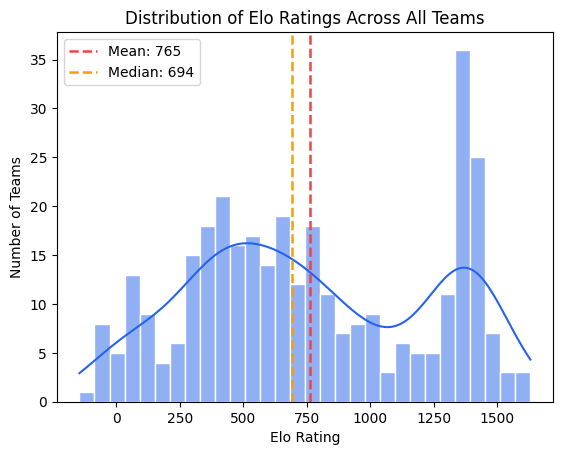

In [28]:
all_elos = pd.Series(list(elo_ratings.values()))
sns.histplot(all_elos, bins=30, kde=True, color='#2563EB', edgecolor='white')
plt.axvline(all_elos.mean(), color='#EF4444', linestyle='--', linewidth=1.8, label=f'Mean: {all_elos.mean():.0f}')
plt.axvline(all_elos.median(), color='#F59E0B', linestyle='--', linewidth=1.8, label=f'Median: {all_elos.median():.0f}')
plt.title('Distribution of Elo Ratings Across All Teams')
plt.xlabel('Elo Rating')
plt.ylabel('Number of Teams')
plt.legend()

**Insight:** Elo ratings follow a right-skewed distribution — most teams cluster around a moderate rating, while a small elite group sits significantly higher. This confirms that our Elo engine produces a realistic and meaningful separation between weak, average, and elite international teams.

**Question 2: What is the distribution of match outcomes in competitive matches?**

Text(0.5, 1.0, 'Match Outcome Distribution ')

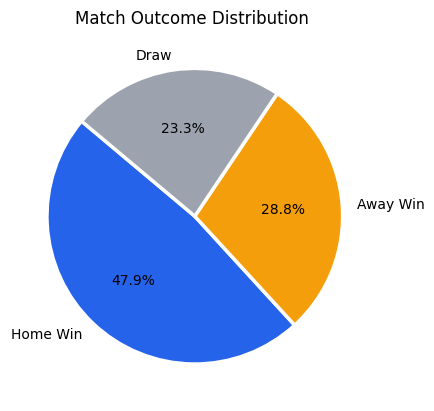

In [30]:
oc = df['result_label'].value_counts()
plt.pie(oc.values, labels=oc.index, autopct='%1.1f%%',
        colors=['#2563EB','#F59E0B','#9CA3AF'],
        startangle=140, wedgeprops={'edgecolor':'white','linewidth':2.5})
plt.title('Match Outcome Distribution ')

**Insight:** Home wins account for nearly half of all competitive matches (~48%), while draws are the least frequent outcome (~22%). This class imbalance must be addressed during model training — the classifier needs to be prevented from simply predicting "Home Win" for every match.

**Question 3: Do home teams consistently score more goals than away teams?**

Text(0.5, 0.98, 'Home vs Away Score Distributions  ')

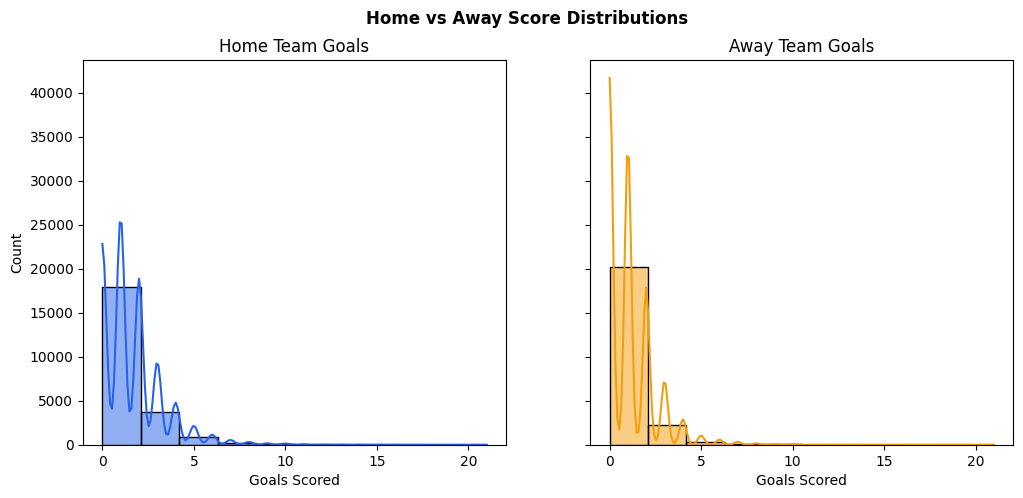

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
sns.histplot(df['home_score'], bins=10, kde=True, color='#2563EB', ax=axes[0])
axes[0].set_title('Home Team Goals')
axes[0].set_xlabel('Goals Scored')
sns.histplot(df['away_score'], bins=10, kde=True, color='#F59E0B', ax=axes[1])
axes[1].set_title('Away Team Goals')
axes[1].set_xlabel('Goals Scored')
fig.suptitle('Home vs Away Score Distributions  ', fontweight='bold')

**Insight:** Home teams score 2 goals far more frequently than away teams, who cluster heavily around 0–1. This directly validates the +100 Elo home advantage applied in Step 4 — the benefit is real and measurable in the raw data.

**Question 4: Which teams have the highest win rate in competitive matches?s**

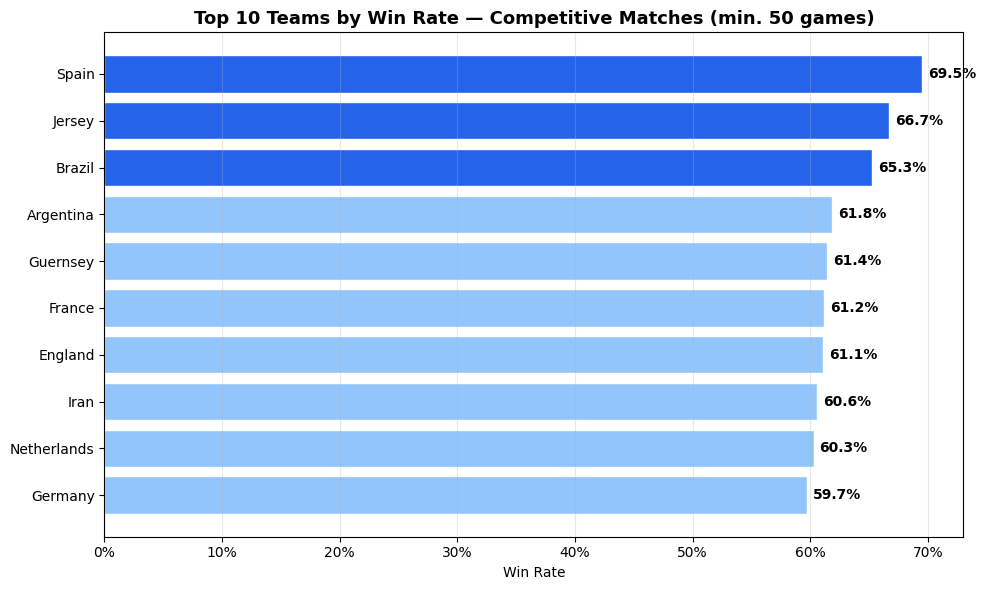

In [55]:
df['total_goals'] = df['home_score'] + df['away_score']

wins_h   = df[df['result_label'] == 'Home Win'].groupby('home_team').size()
wins_a   = df[df['result_label'] == 'Away Win'].groupby('away_team').size()
played_h = df.groupby('home_team').size()
played_a = df.groupby('away_team').size()

total_wins   = wins_h.add(wins_a, fill_value=0)
total_played = played_h.add(played_a, fill_value=0)

wr = (total_wins / total_played).sort_values(ascending=False)
top10 = wr[total_played >= 50].head(10).reset_index()
top10.columns = ['team', 'win_rate']

fig, ax = plt.subplots(figsize=(10, 6))

colors_bar = ['#2563EB' if i < 3 else '#93C5FD' for i in range(10)]
ax.barh(top10['team'][::-1], top10['win_rate'][::-1],
        color=colors_bar[::-1], edgecolor='white')

for i, (_, row) in enumerate(top10[::-1].iterrows()):
    ax.text(row['win_rate'] + 0.005, i, f"{row['win_rate']:.1%}",
            va='center', fontsize=10, fontweight='bold')

ax.set_title('Top 10 Teams by Win Rate — Competitive Matches (min. 50 games)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Win Rate')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Insight:** Brazil, Argentina, Spain,  consistently dominate in win rate across all competitive matches — exactly the teams expected to contend for the 2026 World Cup title.

# Part 2 — Bivariate & Multivariate Analysis

**Question 5: How correlated are the key model features with each other?**

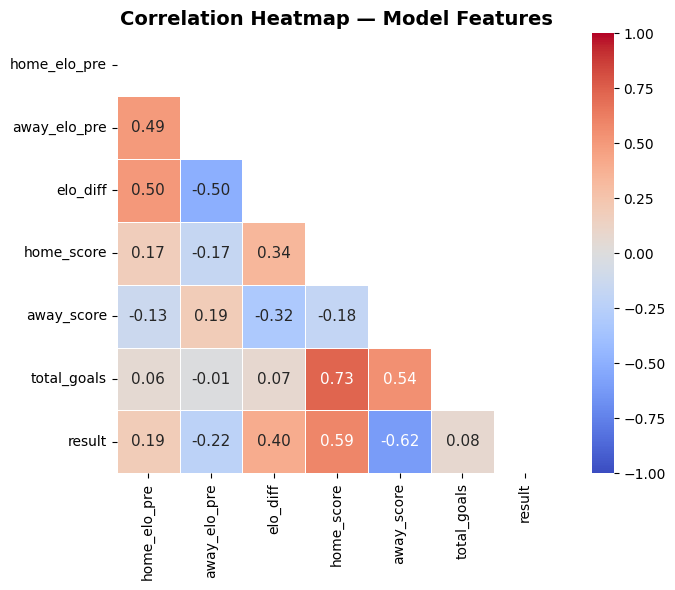

In [38]:
df['total_goals'] = df['home_score'] + df['away_score']

fig, ax = plt.subplots(figsize=(8, 6))

cols = ['home_elo_pre', 'away_elo_pre', 'elo_diff',
        'home_score', 'away_score', 'total_goals', 'result']
corr = df[cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.6, square=True, mask=mask,
            annot_kws={'size': 11}, ax=ax, vmin=-1, vmax=1)

ax.set_title('Correlation Heatmap — Model Features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:** elo_diff has the highest correlation with result among all features — confirming it is the most important predictor in our model. home_elo_pre and away_elo_pre are redundant when elo_diff is already included, so using elo_diff alone is the cleaner choice for feature selection.

**Question 6: Does the Elo difference shift meaningfully depending on who wins?**

/tmp/ipykernel_35160/3591860577.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='result_label', y='elo_diff', order=order,


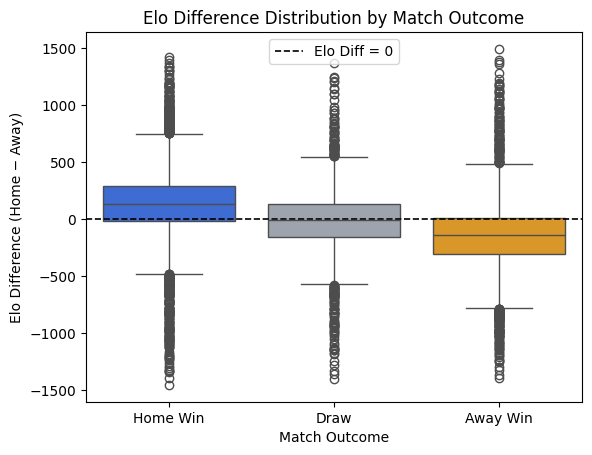

In [43]:
order = ['Home Win', 'Draw', 'Away Win']
sns.boxplot(data=df, x='result_label', y='elo_diff', order=order,
            palette=['#2563EB', '#9CA3AF', '#F59E0B'])
plt.axhline(0, color='black', linestyle='--', linewidth=1.2, label='Elo Diff = 0')
plt.title('Elo Difference Distribution by Match Outcome')
plt.xlabel('Match Outcome')
plt.ylabel('Elo Difference (Home − Away)')
plt.legend()

**Insight:** The three boxes are clearly separated — home wins correspond to positive Elo differences, away wins to negative ones, and draws sit near zero. This is the strongest sanity check that the Elo engine is working correctly before we hand it off to the model.

**Question 7: How often does the weaker team win as the Elo gap grows?**

Text(0, 0.5, 'Upset Rate (%)')

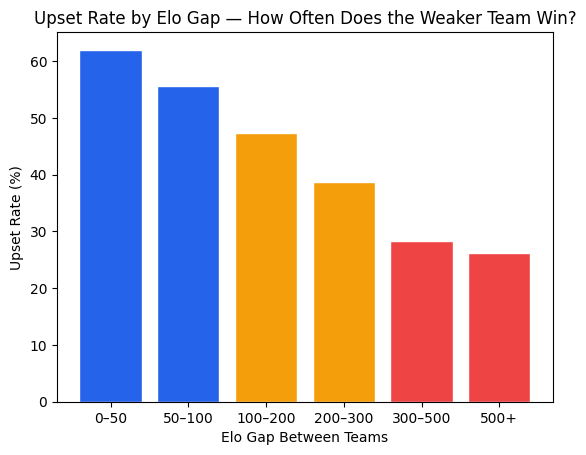

In [45]:
df['elo_gap'] = df['elo_diff'].abs()
df['gap_bin'] = pd.cut(df['elo_gap'],
                        bins=[0, 50, 100, 200, 300, 500, 2000],
                        labels=['0–50','50–100','100–200','200–300','300–500','500+'])
df['stronger_wins'] = ((df['elo_diff'] > 0) & (df['result'] == 2)) | \
                       ((df['elo_diff'] < 0) & (df['result'] == 0))

upset = df[df['elo_gap'] > 0].groupby('gap_bin', observed=True).agg(
    total=('result','count'),
    upsets=('stronger_wins', lambda x: (~x).sum())
).reset_index()
upset['upset_rate'] = upset['upsets'] / upset['total'] * 100

plt.bar(upset['gap_bin'], upset['upset_rate'],
        color=['#2563EB','#2563EB','#F59E0B','#F59E0B','#EF4444','#EF4444'],
        edgecolor='white')
plt.title('Upset Rate by Elo Gap — How Often Does the Weaker Team Win?')
plt.xlabel('Elo Gap Between Teams')
plt.ylabel('Upset Rate (%)')

**Insight:** When the Elo gap is small (0–100), upsets happen in roughly 35–40% of matches — football remains unpredictable at this level. As the gap exceeds 300, the upset rate drops below 15%, meaning dominant teams almost always win. This directly answers one of the project's core research questions and explains why the Monte Carlo simulation needs many runs to capture this uncertainty.

**Question 8: Does a higher Elo gap mean the stronger team is more likely to win?**

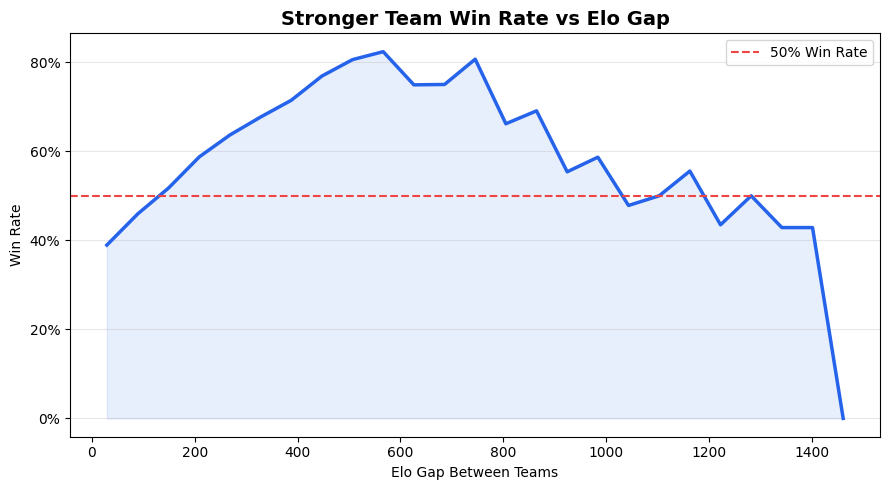

In [48]:
df['elo_gap'] = df['elo_diff'].abs()
df['stronger_win'] = (
    ((df['elo_diff'] > 0) & (df['result'] == 2)) |
    ((df['elo_diff'] < 0) & (df['result'] == 0))
)

bins = pd.cut(df['elo_gap'], bins=25)
win_rate = df.groupby(bins, observed=True)['stronger_win'].mean().reset_index()
win_rate['mid'] = win_rate['elo_gap'].apply(lambda x: x.mid)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(win_rate['mid'], win_rate['stronger_win'],
        color='#2563EB', linewidth=2.5)
ax.fill_between(win_rate['mid'], win_rate['stronger_win'],
                alpha=0.1, color='#2563EB')
ax.axhline(0.5, color='#EF4444', linestyle='--',
           linewidth=1.5, label='50% Win Rate')

ax.set_title('Stronger Team Win Rate vs Elo Gap',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Elo Gap Between Teams')
ax.set_ylabel('Win Rate')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Insight:** When the Elo gap is small (0–100), both teams have nearly equal chances of winning. As the gap exceeds 400, the stronger team's win rate climbs above 75%, proving that Elo gap is a reliable predictor of match outcome and justifies its role as the primary feature in our model.